In [27]:
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt

In [28]:
class Complex(keras.layers.Layer):
    def __init__(self, units, input_dim):
        super().__init__()

        self.Re_W = self.add_weight(
            shape = (units, input_dim),
            initializer = "random_uniform",
            trainable = True,
            dtype = tf.dtypes.float32
        )

        self.Im_W = self.add_weight(
            shape = (units, input_dim),
            initializer = "random_uniform",
            trainable = True,
            dtype = tf.dtypes.float32
        )

        self.Re_b = self.add_weight(
            shape = (units, 1),
            initializer = "zeros",
            trainable = True,
            dtype = tf.dtypes.float32
        )

        self.Im_b = self.add_weight(
            shape = (units, 1),
            initializer = "zeros",
            trainable = True,
            dtype = tf.dtypes.float32
        )

    def call(self, inputs):
        W = tf.complex(self.Re_W, self.Im_W)
        b = tf.complex(self.Re_b, self.Im_b)

        return tf.math.exp(W@inputs + b)


class Linear(keras.layers.Layer):
    def __init__(self, units, input_dim):
        super().__init__()

        self.Re_W = self.add_weight(
            shape = (units, input_dim),
            initializer = "random_uniform",
            trainable = True,
            dtype = tf.dtypes.float32
        )

        self.Im_W = self.add_weight(
            shape = (units, input_dim),
            initializer = "random_uniform",
            trainable = True,
            dtype = tf.dtypes.float32
        )

        self.Re_b = self.add_weight(
            shape = (units, 1),
            initializer = "zeros",
            trainable = True,
            dtype = tf.dtypes.float32
        )

        self.Im_b = self.add_weight(
            shape = (units, 1),
            initializer = "zeros",
            trainable = True,
            dtype = tf.dtypes.float32
        )

    def call(self, inputs):
        W = tf.complex(self.Re_W, self.Im_W)
        b = tf.complex(self.Re_b, self.Im_b)

        return (W@inputs + b)

In [29]:
layer1 = Complex(units = 4, input_dim = 1)
layer2 = Linear(units = 1, input_dim = 4)
model = keras.Sequential([layer1, layer2])

x = tf.constant([[0.0]], dtype = tf.complex64)
y = model([x])

print(y)

tf.Tensor([[[-0.00041914-0.03453454j]]], shape=(1, 1, 1), dtype=complex64)


In [31]:
Z = []
W = []

n = 1000

for k in range(n):
  theta = (k/n)*2*np.pi

  z = tf.complex(real = np.cos(theta), imag = np.sin(theta))
  z = tf.reshape(z, (1, 1))
  Z.append(z)

  w = z*z
  w = tf.cast(w, tf.dtypes.complex64)
  W.append(w)


# shuffling the dataset
dataset = list(zip(Z, W))
random.shuffle(dataset)
Z, W = zip(*dataset)


optimizer = keras.optimizers.Adam(learning_rate = 0.001)

36.042217
36.01554
36.01281
36.010693
36.008213
36.004898
36.000263
35.993584
35.983765
35.96896
35.94597
35.90903
35.84743
35.740837
35.55013
35.200184
34.54946
33.344284
31.178543
27.550787
22.316252
19.098122
18.34826
17.904013
17.483816
17.040438
16.52979
15.900462
15.083957
13.993239
12.538223
10.671414
8.463968
6.135977
4.0542054
2.6517901
2.0145023
1.7703881
1.5842463
1.4680147
1.3516872
1.2677724
1.1954653
1.1466602
1.107694
1.0738692
1.0457916
1.0195217
1.0033722
0.9827039
0.96299493
0.94725466
0.9342977
0.92264295
0.9120644
0.9025483
0.8939062
0.88598967
0.87867075
0.8718428
0.86542124
0.8593371
0.8535374
0.84797794
0.84262353
0.83744717
0.83242536
0.8275406
0.82277703
0.81812125
0.8135621
0.8090934
0.80470556
0.8003931
0.79615
0.79197246
0.7878558
0.7837962
0.779792
0.7758398
0.77193624
0.7680803
0.76426977
0.76050395
0.7567803
0.75309795
0.74945706
0.7458551
0.7422917
0.7387671
0.7352817
0.73183465
0.7284274
0.7250594
0.7217331
0.7184502
0.7152131
0.7120247
0.7088897
0.7058

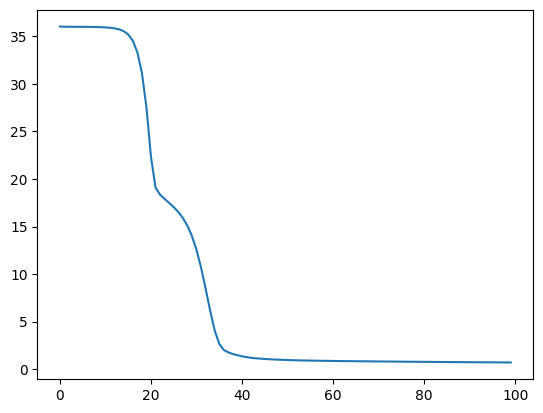

In [32]:
epochs = 100
epoch_losses = []


for epoch in range(epochs):

  epoch_loss = 0.0

  for k in range(36):
    k0 = 10*k

    Z_batch = Z[k0:k0+10]
    W_batch = tf.stack(W[k0:k0+10])

    with tf.GradientTape() as tape:
      W_batch_pred = model(Z_batch, training = True)
      loss = tf.reduce_mean(tf.math.abs(W_batch - W_batch_pred))

    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    epoch_loss += loss.numpy()

  print(epoch_loss)
  epoch_losses.append(epoch_loss)

plt.plot(epoch_losses)
plt.show()